In [31]:

#GEREKLİ KÜTÜPHANELER

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import StratifiedKFold, ParameterSampler, train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report,
    roc_auc_score, precision_recall_curve, auc, cohen_kappa_score, precision_score, recall_score
)
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12



Gerekli tüm kütüphaneleri import ediyorum

In [32]:
#SEED AYARLARI VE CIHAZ

def set_seed(seed=42):
    """Tüm rastgelelik kaynaklarını sabitle"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🎯 Kullanılan cihaz: {device}")
print(f"🎯 CUDA kullanılabilir: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"🎯 GPU: {torch.cuda.get_device_name(0)}")



🎯 Kullanılan cihaz: cuda
🎯 CUDA kullanılabilir: True
🎯 GPU: NVIDIA GeForce RTX 4050 Laptop GPU


Rastgeleliği sabitledim ve GPU'yu hazırladım.

In [33]:
#KONFİGÜRASYON

class Config:
    """Tüm yapılandırma ayarları"""
    # Dataset
    DATASET_DIR = r"C:\Users\Kardelen\Desktop\dlp\garbage-dataset"
    
    IMG_SIZE = 224
    BACKBONE = "densenet121"
    
    BATCH_SIZE = 32
    NUM_WORKERS = 0
    N_SPLITS = 5 
    RANDOM_STATE = 42
    
    RANDOM_SEARCH_ITER = 5
    RANDOM_SEARCH_PARAMS = {
        'lr': [1e-4, 5e-4, 1e-3, 1e-5],
        'weight_decay': [1e-4, 1e-5, 1e-3],
        'dropout': [0.3, 0.5, 0.7]
    }
    
    PHASE1_EPOCHS = 5  # Head training
    PHASE2_EPOCHS = 20 # Fine-tuning
    EARLY_STOPPING_PATIENCE = 5
    
    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD = [0.229, 0.224, 0.225]

config = Config()



Proje ayarlarını bir sınıfta topladım. Görüntülerin boyutu, kullanılacak model, batch boyutu gibi temel değerleri belirledim. Ayrıca hiperparametre arama için aranacak değerleri ve görüntü normalizasyon ayarlarını ekledim.


📁 DATASET YÜKLENİYOR
✅ 10 sınıf bulundu:
    0: battery
    1: biological
    2: cardboard
    3: clothes
    4: glass
    5: metal
    6: paper
    7: plastic
    8: shoes
    9: trash


📸 Görüntüler okunuyor: 100%|██████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 47.59it/s]



📊 Dataset istatistikleri:
   Toplam görüntü: 19762
   Sınıf sayısı: 10


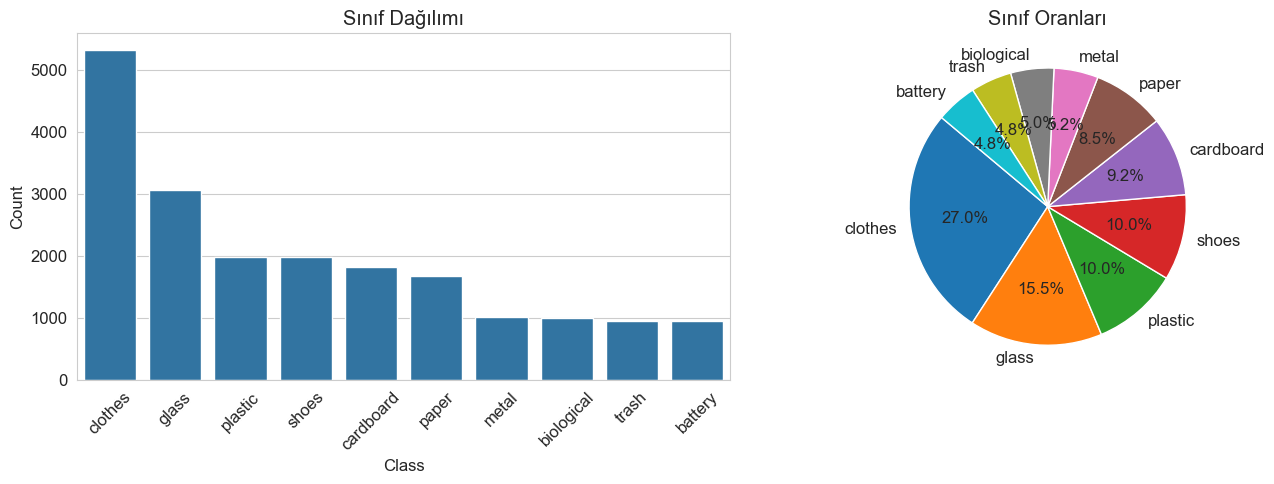

In [34]:
#DATASET YÜKLEME VE ANALİZ

print("\n" + "="*60)
print("📁 DATASET YÜKLENİYOR")
print("="*60)

class_names = sorted([
    d for d in os.listdir(config.DATASET_DIR)
    if os.path.isdir(os.path.join(config.DATASET_DIR, d))
])
num_classes = len(class_names)

print(f"✅ {num_classes} sınıf bulundu:")
for i, cls in enumerate(class_names):
    print(f"   {i:2d}: {cls}")

class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

data = []
for cls in tqdm(class_names, desc="📸 Görüntüler okunuyor"):
    cls_path = os.path.join(config.DATASET_DIR, cls)
    images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    for img in images:
        data.append({
            "image_path": os.path.join(cls_path, img),
            "label": class_to_idx[cls],
            "class_name": cls
        })

df = pd.DataFrame(data)
print(f"\n📊 Dataset istatistikleri:")
print(f"   Toplam görüntü: {len(df)}")
print(f"   Sınıf sayısı: {num_classes}")

class_distribution = df["class_name"].value_counts().reset_index()
class_distribution.columns = ["Class", "Count"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x="Class", y="Count", data=class_distribution, ax=axes[0])
axes[0].set_title("Sınıf Dağılımı")
axes[0].tick_params(axis='x', rotation=45)

axes[1].pie(class_distribution["Count"], labels=class_distribution["Class"], 
           autopct="%1.1f%%", startangle=140)
axes[1].set_title("Sınıf Oranları")
plt.tight_layout()
plt.show()



Dataset'i yükledim ve analiz ettim. Klasörlerden sınıfları okuyup görüntü yollarını bir DataFrame'de topladım. Her sınıftaki görüntü sayısını hesaplayıp görselleştirdim. Çubuk grafik ve pasta grafik ile dağılımı inceledim.

In [35]:
#DATA TRANSFORMS

print("\n" + "="*60)
print("🔄 DATA AUGMENTATION AYARLARI")
print("="*60)

train_transforms = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomResizedCrop(config.IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=config.IMAGENET_MEAN, std=config.IMAGENET_STD)
])

val_test_transforms = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=config.IMAGENET_MEAN, std=config.IMAGENET_STD)
])

print("✅ Transformations tanımlandı")
print(f"   Train transforms: {len(train_transforms.transforms)} augmentation")
print(f"   Val/Test transforms: Temiz")




🔄 DATA AUGMENTATION AYARLARI
✅ Transformations tanımlandı
   Train transforms: 7 augmentation
   Val/Test transforms: Temiz


Veri artırma ve ön işleme ayarlarını yaptım. Eğitim için yatay çevirme, döndürme, renk ayarı ve kırpma gibi çeşitlendirmeler ekledim. 

In [36]:
#CUSTOM DATASET SINIFI

class TrashDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_path = row["image_path"]
        label = row["label"]
        class_name = row["class_name"]
        
        image = Image.open(image_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
            
        return {
            "image": image,
            "label": label,
            "class_name": class_name,
            "image_path": image_path
        }


Özel bir Dataset sınıfı oluşturdum. Bu sınıf, görüntüleri yükleyip transform işlemlerini uyguluyor.Her görüntüyü açıp RGB'ye çeviriyor ve belirlenen dönüşümleri uyguluyor. Görüntü, etiket, sınıf adı ve dosya yolu bilgilerini döndürüyor.


✂️  DATA SPLITTING
📊 Split istatistikleri:
   Train (final) : 12647 görüntü (64.0%)
   Validation    : 3162 görüntü (16.0%)
   Test          : 3953 görüntü (20.0%)


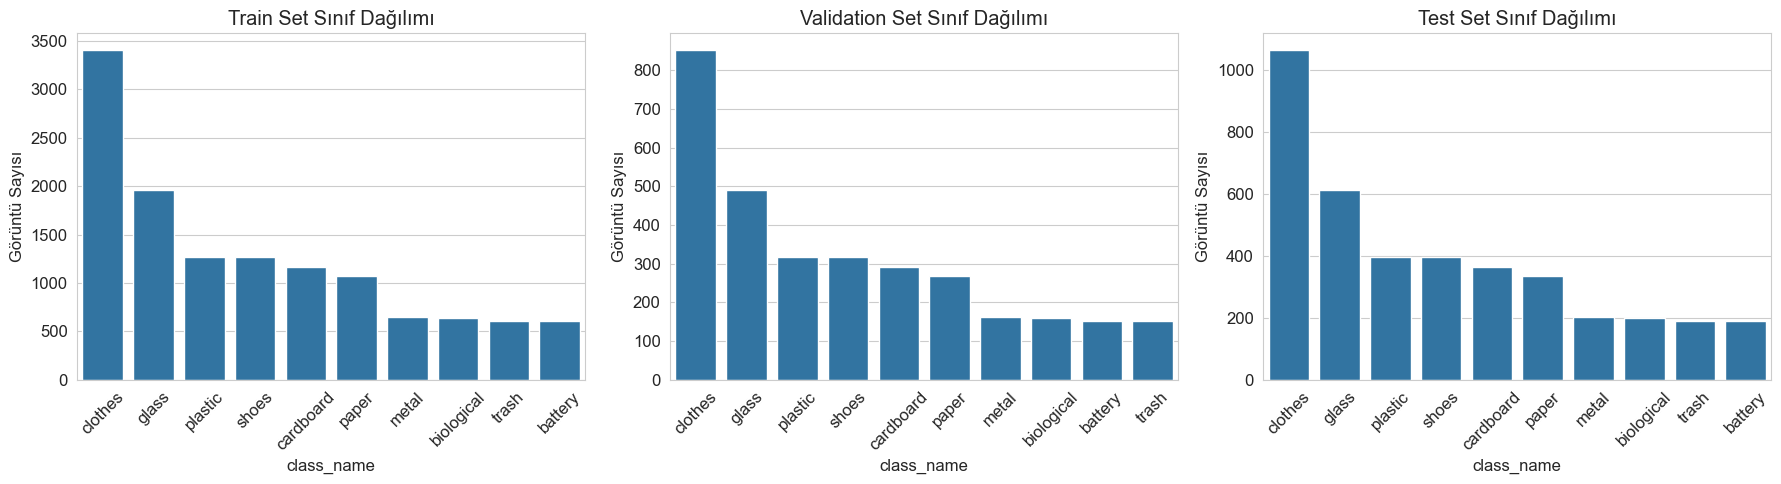


🔄 DATALOADERS OLUŞTURULUYOR
✅ DataLoaders oluşturuldu:
   Train batches : 396
   Val batches   : 99
   Test batches  : 124


In [37]:
#DATA SPLITTING

print("\n" + "="*60)
print("✂️  DATA SPLITTING")
print("="*60)

X = df["image_path"].values
y = df["label"].values

# Stratified K-Fold
skf = StratifiedKFold(n_splits=config.N_SPLITS, shuffle=True, random_state=config.RANDOM_STATE)
folds = list(skf.split(X, y))

# İlk fold'u kullan
train_idx, test_idx = folds[0]
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.2, 
    stratify=y_train,
    random_state=config.RANDOM_STATE
)

train_df = df.iloc[train_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

train_final_df = pd.DataFrame({
    "image_path": X_train_final,
    "label": y_train_final,
    "class_name": [idx_to_class[label] for label in y_train_final]
})

val_df = pd.DataFrame({
    "image_path": X_val,
    "label": y_val,
    "class_name": [idx_to_class[label] for label in y_val]
})

print(f"📊 Split istatistikleri:")
print(f"   Train (final) : {len(train_final_df)} görüntü ({len(train_final_df)/len(df)*100:.1f}%)")
print(f"   Validation    : {len(val_df)} görüntü ({len(val_df)/len(df)*100:.1f}%)")
print(f"   Test          : {len(test_df)} görüntü ({len(test_df)/len(df)*100:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, data_df) in enumerate([
    ("Train", train_final_df),
    ("Validation", val_df),
    ("Test", test_df)
]):
    dist = data_df["class_name"].value_counts()
    sns.barplot(x=dist.index, y=dist.values, ax=axes[idx])
    axes[idx].set_title(f"{name} Set Sınıf Dağılımı")
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].set_ylabel("Görüntü Sayısı")

plt.tight_layout()
plt.show()


#DATALOADERS

print("\n" + "="*60)
print("🔄 DATALOADERS OLUŞTURULUYOR")
print("="*60)

train_dataset = TrashDataset(train_final_df, transform=train_transforms)
val_dataset = TrashDataset(val_df, transform=val_test_transforms)
test_dataset = TrashDataset(test_df, transform=val_test_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=config.NUM_WORKERS,
    pin_memory= False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"✅ DataLoaders oluşturuldu:")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")



Veriyi katmanlı bir şekilde böldüm. Önce 5 katlı çapraz doğrulama yapısı kurup ilk fold'u seçtim. Sonra eğitim setini %80 eğitim, %20 doğrulama olacak şekilde ayırdım. Her setin sınıf dağılımını kontrol ettim ve görselleştirdim. Son olarak, her set için DataLoader'lar oluşturdum. Böylece model eğitimi için veri hazır hale geldi.

In [38]:
#CLASS WEIGHTS

print("\n" + "="*60)
print("⚖️  CLASS WEIGHTS HESAPLANIYOR")
print("="*60)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_final_df["label"]),
    y=train_final_df["label"]
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print("📊 Class weights:")
for idx, weight in enumerate(class_weights):
    print(f"   {idx_to_class[idx]:<15}: {weight:.4f}")




⚖️  CLASS WEIGHTS HESAPLANIYOR
📊 Class weights:
   battery        : 2.0939
   biological     : 1.9823
   cardboard      : 1.0828
   clothes        : 0.3710
   glass          : 0.6456
   metal          : 1.9368
   paper          : 1.1765
   plastic        : 0.9966
   shoes          : 0.9990
   trash          : 2.0870


Sınıf dengesizliğini gidermek için class weights hesapladım. Her sınıfa, görüntü sayısına ters orantılı ağırlıklar atadım. Bu ağırlıkları CrossEntropyLoss fonksiyonuna verdim. Böylece az örnek olan sınıflara daha fazla önem verilerek modelin daha dengeli öğrenmesini sağladım.

In [39]:
#MODEL OLUŞTURMA FONKSİYONU

def get_densenet121(num_classes, dropout_rate=0.5, pretrained=True):
    """DenseNet121 modelini oluştur"""
    if pretrained:
        model = models.densenet121(weights="DEFAULT")
    else:
        model = models.densenet121(weights=None)
    
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout_rate),
        nn.Linear(512, num_classes)
    )
    
    return model



DenseNet121 modelini hazırladım. Önceden eğitilmiş ağırlıkları kullandım. Modelin son katmanını değiştirdim: önce 512 nöronlu bir gizli katman, ReLU aktivasyonu, dropout ve son olarak sınıf sayısı kadar çıktı katmanı ekledim. Böylece model bizim sınıflandırma problemimize uyarlandı.



In [40]:
#YARDIMCI FONKSİYONLAR

def calculate_accuracy(outputs, labels):
    """Accuracy hesapla"""
    _, preds = torch.max(outputs, 1)
    return (preds == labels).sum().item() / labels.size(0)

class EarlyStopping:
    """Early stopping sınıfı"""
    def __init__(self, patience=5, delta=0.0):
        self.patience = patience
        self.delta = delta
        self.best_loss = np.inf
        self.counter = 0
        self.early_stop = False
        
    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

def train_one_epoch(model, loader, optimizer, criterion, device):
    """Bir epoch eğitim"""
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    
    for batch in tqdm(loader, desc="Eğitim", leave=False):
        images = batch["image"].to(device)
        labels = batch["label"].to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        running_acc += calculate_accuracy(outputs, labels)
    
    return running_loss / len(loader), running_acc / len(loader)

def validate_one_epoch(model, loader, criterion, device):
    """Validation"""
    model.eval()
    running_loss = 0.0
    running_acc = 0.0
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Validation", leave=False):
            images = batch["image"].to(device)
            labels = batch["label"].to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            running_acc += calculate_accuracy(outputs, labels)
    
    return running_loss / len(loader), running_acc / len(loader)

def unfreeze_last_blocks(model, num_blocks=1):
    """Son blokları açar"""
    print(f"\n🔓 Sadece son {num_blocks} block açılıyor...")
    
    # Önce hepsini dondur
    for param in model.features.parameters():
        param.requires_grad = False
    
    if num_blocks == 1:
        blocks_to_unfreeze = ['denseblock4', 'norm5']
    elif num_blocks == 2:
        blocks_to_unfreeze = ['denseblock3', 'transition3', 'denseblock4', 'norm5']
    else:
        blocks_to_unfreeze = ['denseblock2', 'transition2', 'denseblock3', 
                             'transition3', 'denseblock4', 'norm5']
    
    # Blokları aç
    for name, param in model.features.named_parameters():
        if any(block in name for block in blocks_to_unfreeze):
            param.requires_grad = True
    
    for param in model.classifier.parameters():
        param.requires_grad = True
    
    trainable = sum(p.requires_grad for p in model.parameters())
    total = sum(1 for _ in model.parameters())
    print(f"   Eğitilebilir parametreler: {trainable}/{total}")


Eğitim sürecini yönetmek için yardımcı fonksiyonlar yazdım. Accuracy hesaplama, early stopping kontrolü, bir epoch eğitim ve validation işlemlerini içeriyor. Ayrıca ince ayar (fine-tuning) için modelin son katmanlarını açan bir fonksiyon ekledim. Böylece transfer learning sürecini kontrol edebiliyorum.

In [41]:
#RANDOM SEARCH

def random_search_optimization(param_grid, n_iter=5):
    """
    OPTİMİZE EDİLMİŞ RANDOM SEARCH
    - Model, optimizer ve scheduler state'lerini kaydeder
    - Gerçek entegrasyon sağlar
    """
    print("\n" + "="*60)
    print("🔍 RANDOM SEARCH BAŞLIYOR")
    print("="*60)
    
    param_list = list(ParameterSampler(
        param_grid, n_iter=n_iter, random_state=config.RANDOM_STATE
    ))
    
    results = []
    
    for i, params in enumerate(param_list):
        print(f"\n🎯 DENEME {i+1}/{n_iter}")
        print(f"   LR: {params['lr']:.0e}, WD: {params['weight_decay']:.0e}, Dropout: {params['dropout']}")
        
        #MODEL OLUŞTUR
        model_rs = get_densenet121(
            num_classes=num_classes,
            dropout_rate=params['dropout'],
            pretrained=True
        ).to(device)
        
        #BACKBONE DONDUR (HEAD TRAINING)
        for param in model_rs.features.parameters():
            param.requires_grad = False
        
        #OPTIMIZER
        optimizer_rs = optim.AdamW(
            filter(lambda p: p.requires_grad, model_rs.parameters()),
            lr=params['lr'],
            weight_decay=params['weight_decay']
        )
        
        scheduler_rs = optim.lr_scheduler.CosineAnnealingLR(
            optimizer_rs, T_max=5, eta_min=1e-5
        )
        
        #HEAD TRAINING
        early_stopping = EarlyStopping(patience=2)
        best_val_loss = np.inf
        best_val_acc = 0
        
        print("Head training ")
        
        for epoch in range(5):
            train_loss, train_acc = train_one_epoch(
                model_rs, train_loader, optimizer_rs, criterion, device
            )
            
            val_loss, val_acc = validate_one_epoch(
                model_rs, val_loader, criterion, device
            )
            
            scheduler_rs.step()
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_val_acc = val_acc
                best_model_state = model_rs.state_dict().copy()
                best_optimizer_state = optimizer_rs.state_dict().copy()
                best_scheduler_state = scheduler_rs.state_dict().copy()
            
            early_stopping(val_loss)
            if early_stopping.early_stop:
                break
        
        #SONUÇLARI KAYDET
        results.append({
            'params': params,
            'best_val_loss': best_val_loss,
            'best_val_acc': best_val_acc,
            'model_state': best_model_state,
            'optimizer_state': best_optimizer_state,
            'scheduler_state': best_scheduler_state
        })
        
        print(f"   ✓ Val Loss: {best_val_loss:.4f}, Val Acc: {best_val_acc:.4f}")
    
    # EN İYİ PARAMETRELERİ BUL
    best_result = min(results, key=lambda x: x['best_val_loss'])
   
    print("\n" + "="*60)
    print("📊 RANDOM SEARCH SONUÇLARI")
    print("="*60)
    
    results_df = pd.DataFrame([{
        'Trial': i+1,
        'LR': f"{r['params']['lr']:.0e}",
        'WD': f"{r['params']['weight_decay']:.0e}",
        'Dropout': r['params']['dropout'],
        'Val Loss': f"{r['best_val_loss']:.4f}",
        'Val Acc': f"{r['best_val_acc']:.4f}"
    } for i, r in enumerate(results)])
    
    print(results_df.to_string(index=False))
    
    print(f"\n🏆 EN İYİ PARAMETRELER:")
    print(f"   LR: {best_result['params']['lr']}")
    print(f"   Weight Decay: {best_result['params']['weight_decay']}")
    print(f"   Dropout: {best_result['params']['dropout']}")
    print(f"   Validation Loss: {best_result['best_val_loss']:.4f}")
    print(f"   Validation Accuracy: {best_result['best_val_acc']:.4f}")
    
    return best_result, results


Random search yaparak en iyi hiperparametreleri buldum. Her denemede dropout, learning rate ve weight decay değerlerini değiştirip modeli eğittim. En düşük validation loss'a sahip parametre setini seçtim.

In [42]:

#RANDOM SEARCH ÇALIŞTIR

best_result, all_results = random_search_optimization(
    param_grid=config.RANDOM_SEARCH_PARAMS,
    n_iter=config.RANDOM_SEARCH_ITER
)

print("\n" + "="*60)
print("🚀 RANDOM SEARCH PARAMETRELERİ İLE MODEL OLUŞTURULUYOR")
print("="*60)

#Modeli oluştur
model = get_densenet121(
    num_classes=num_classes,
    dropout_rate=best_result['params']['dropout'],
    pretrained=True  # ImageNet weights ile başla
).to(device)

print("✅ Model ImageNet weights ile oluşturuldu")

#Backbone'u dondur
for param in model.features.parameters():
    param.requires_grad = False

print("🔒 Backbone donduruldu")

optimizer = optim.AdamW(
    model.classifier.parameters(),
    lr=best_result['params']['lr'],
    weight_decay=best_result['params']['weight_decay']
)

print("✅ Optimizer random search parametreleriyle oluşturuldu")

#Scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config.PHASE1_EPOCHS,
    eta_min=1e-5
)

print(f"\n📊 KULLANILAN PARAMETRELER (Random Search'ten):")
print(f"   Learning Rate: {best_result['params']['lr']:.0e}")
print(f"   Weight Decay: {best_result['params']['weight_decay']:.0e}")
print(f"   Dropout: {best_result['params']['dropout']}")
print(f"   Random Search Validation Loss: {best_result['best_val_loss']:.4f}")



🔍 RANDOM SEARCH BAŞLIYOR

🎯 DENEME 1/5
   LR: 1e-05, WD: 1e-03, Dropout: 0.7
Head training 


   ✓ Val Loss: 1.2050, Val Acc: 0.8319

🎯 DENEME 2/5
   LR: 1e-04, WD: 1e-05, Dropout: 0.5
Head training 


   ✓ Val Loss: 0.3950, Val Acc: 0.9025

🎯 DENEME 3/5
   LR: 1e-04, WD: 1e-03, Dropout: 0.7
Head training 


   ✓ Val Loss: 0.4326, Val Acc: 0.8977

🎯 DENEME 4/5
   LR: 1e-03, WD: 1e-04, Dropout: 0.7
Head training 


   ✓ Val Loss: 0.3082, Val Acc: 0.9175

🎯 DENEME 5/5
   LR: 5e-04, WD: 1e-05, Dropout: 0.5
Head training 


   ✓ Val Loss: 0.3011, Val Acc: 0.9225

📊 RANDOM SEARCH SONUÇLARI
 Trial    LR    WD  Dropout Val Loss Val Acc
     1 1e-05 1e-03      0.7   1.2050  0.8319
     2 1e-04 1e-05      0.5   0.3950  0.9025
     3 1e-04 1e-03      0.7   0.4326  0.8977
     4 1e-03 1e-04      0.7   0.3082  0.9175
     5 5e-04 1e-05      0.5   0.3011  0.9225

🏆 EN İYİ PARAMETRELER:
   LR: 0.0005
   Weight Decay: 1e-05
   Dropout: 0.5
   Validation Loss: 0.3011
   Validation Accuracy: 0.9225

🚀 RANDOM SEARCH PARAMETRELERİ İLE MODEL OLUŞTURULUYOR
✅ Model ImageNet weights ile oluşturuldu
🔒 Backbone donduruldu
✅ Optimizer random search parametreleriyle oluşturuldu

📊 KULLANILAN PARAMETRELER (Random Search'ten):
   Learning Rate: 5e-04
   Weight Decay: 1e-05
   Dropout: 0.5
   Random Search Validation Loss: 0.3011


Random search ile bulduğum en iyi hiperparametreleri kullanarak modeli yeniden başlattım. Önceden eğitilmiş DenseNet121 kullandım ve backbone'u dondurdum. Optimizer'ı bulunan learning rate ve weight decay değerleriyle ayarladım. Learning rate scheduler ekledim. Böylece model en optimal ayarlarla eğitime hazır hale geldi.

In [43]:

#PHASE 1: HEAD TRAINING
print("\n" + "="*60)
print("🟢 PHASE 1: HEAD TRAINING (Backbone Frozen)")
print("="*60)

for param in model.features.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

print("🔒 Backbone donduruldu, sadece classifier eğitilecek")

train_losses_phase1 = []
val_losses_phase1 = []
train_accs_phase1 = []
val_accs_phase1 = []

early_stopping = EarlyStopping(patience=config.EARLY_STOPPING_PATIENCE)
best_val_loss = np.inf

#PHASE 1 EĞİTİM
for epoch in range(config.PHASE1_EPOCHS):
    print(f"\n📅 Epoch {epoch+1}/{config.PHASE1_EPOCHS}")
    
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )
    
    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )
    
    scheduler.step()
    
    train_losses_phase1.append(train_loss)
    val_losses_phase1.append(val_loss)
    train_accs_phase1.append(train_acc)
    val_accs_phase1.append(val_acc)
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"   Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"   Val Loss  : {val_loss:.4f} | Val Acc  : {val_acc:.4f}")
    print(f"   LR        : {current_lr:.2e}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
        }, "best_model_phase1.pth")
        print("   💾 Best model kaydedildi (Phase 1)")
    
    early_stopping(val_loss)
    if early_stopping.early_stop:
        print("   ⏹️  Early stopping triggered")
        break




🟢 PHASE 1: HEAD TRAINING (Backbone Frozen)
🔒 Backbone donduruldu, sadece classifier eğitilecek

📅 Epoch 1/5


   Train Loss: 0.8776 | Train Acc: 0.7494
   Val Loss  : 0.4543 | Val Acc  : 0.8731
   LR        : 4.53e-04
   💾 Best model kaydedildi (Phase 1)

📅 Epoch 2/5


   Train Loss: 0.5331 | Train Acc: 0.8411
   Val Loss  : 0.3665 | Val Acc  : 0.9037
   LR        : 3.31e-04
   💾 Best model kaydedildi (Phase 1)

📅 Epoch 3/5


   Train Loss: 0.4594 | Train Acc: 0.8599
   Val Loss  : 0.3358 | Val Acc  : 0.9077
   LR        : 1.79e-04
   💾 Best model kaydedildi (Phase 1)

📅 Epoch 4/5


   Train Loss: 0.4058 | Train Acc: 0.8748
   Val Loss  : 0.3230 | Val Acc  : 0.9157
   LR        : 5.68e-05
   💾 Best model kaydedildi (Phase 1)

📅 Epoch 5/5


   Train Loss: 0.3797 | Train Acc: 0.8846
   Val Loss  : 0.3064 | Val Acc  : 0.9203
   LR        : 1.00e-05
   💾 Best model kaydedildi (Phase 1)


Phase 1'de sadece modelin classifier kısmını eğittim. Backbone tamamen donduruldu. Her epoch'ta train/validation kayıplarını ve doğruluklarını takip ettim. En iyi modeli kaydettim ve early stopping ile gereksiz eğitimi önledim. Böylece model önce yeni sınıflara adapte oldu.

In [45]:

#PHASE 2: FINE-TUNING

print("\n" + "="*60)
print("🔵 PHASE 2: FINE-TUNING (Son Bloklar Açık)")
print("="*60)

# Phase 1'den en iyi modeli yükle
checkpoint = torch.load("best_model_phase1.pth", map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
print("✅ Phase 1 best model yüklendi")

unfreeze_last_blocks(model, num_blocks=1)

optimizer_ft = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=best_result['params']['lr'] * 0.1,  # Daha düşük LR
    weight_decay=best_result['params']['weight_decay']
)

scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ft,
    T_max=config.PHASE2_EPOCHS,
    eta_min=1e-6
)

print(f"\n📊 Fine-tuning ayarları:")
print(f"   Learning Rate: {best_result['params']['lr'] * 0.1:.2e}")
print(f"   Weight Decay: {best_result['params']['weight_decay']}")
print(f"   Eğitilecek parametreler: {sum(p.requires_grad for p in model.parameters())}")

train_losses_phase2 = []
val_losses_phase2 = []
train_accs_phase2 = []
val_accs_phase2 = []

early_stopping_ft = EarlyStopping(patience=config.EARLY_STOPPING_PATIENCE)
best_val_loss_ft = np.inf

# PHASE 2 EĞİTİM
for epoch in range(config.PHASE2_EPOCHS):
    print(f"\n📅 Epoch {epoch+1}/{config.PHASE2_EPOCHS} (Fine-tuning)")
    
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer_ft, criterion, device
    )
    
    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )
    
    scheduler_ft.step()
    
    train_losses_phase2.append(train_loss)
    val_losses_phase2.append(val_loss)
    train_accs_phase2.append(train_acc)
    val_accs_phase2.append(val_acc)
    
    current_lr = optimizer_ft.param_groups[0]['lr']
    print(f"   Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"   Val Loss  : {val_loss:.4f} | Val Acc  : {val_acc:.4f}")
    print(f"   LR        : {current_lr:.2e}")
    
    if val_loss < best_val_loss_ft:
        best_val_loss_ft = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer_ft.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
        }, "best_model_final.pth")
        print("   💾 Best model kaydedildi (Final)")
    
    early_stopping_ft(val_loss)
    if early_stopping_ft.early_stop:
        print("   ⏹️  Early stopping triggered")
        break




🔵 PHASE 2: FINE-TUNING (Son Bloklar Açık)
✅ Phase 1 best model yüklendi

🔓 Sadece son 1 block açılıyor...
   Eğitilebilir parametreler: 102/366

📊 Fine-tuning ayarları:
   Learning Rate: 5.00e-05
   Weight Decay: 1e-05
   Eğitilecek parametreler: 102

📅 Epoch 1/20 (Fine-tuning)


   Train Loss: 0.3484 | Train Acc: 0.8940
   Val Loss  : 0.2455 | Val Acc  : 0.9389
   LR        : 4.97e-05
   💾 Best model kaydedildi (Final)

📅 Epoch 2/20 (Fine-tuning)


   Train Loss: 0.2734 | Train Acc: 0.9148
   Val Loss  : 0.2099 | Val Acc  : 0.9434
   LR        : 4.88e-05
   💾 Best model kaydedildi (Final)

📅 Epoch 3/20 (Fine-tuning)


   Train Loss: 0.2307 | Train Acc: 0.9257
   Val Loss  : 0.1919 | Val Acc  : 0.9482
   LR        : 4.73e-05
   💾 Best model kaydedildi (Final)

📅 Epoch 4/20 (Fine-tuning)


   Train Loss: 0.1917 | Train Acc: 0.9378
   Val Loss  : 0.1853 | Val Acc  : 0.9519
   LR        : 4.53e-05
   💾 Best model kaydedildi (Final)

📅 Epoch 5/20 (Fine-tuning)


...

   Train Loss: 0.0650 | Train Acc: 0.9777
   Val Loss  : 0.1543 | Val Acc  : 0.9612
   LR        : 5.68e-06

📅 Epoch 17/20 (Fine-tuning)


   Train Loss: 0.0607 | Train Acc: 0.9798
   Val Loss  : 0.1544 | Val Acc  : 0.9612
   LR        : 3.67e-06

📅 Epoch 18/20 (Fine-tuning)


   Train Loss: 0.0603 | Train Acc: 0.9804
   Val Loss  : 0.1571 | Val Acc  : 0.9602
   LR        : 2.20e-06

📅 Epoch 19/20 (Fine-tuning)


   Train Loss: 0.0561 | Train Acc: 0.9813
   Val Loss  : 0.1548 | Val Acc  : 0.9615
   LR        : 1.30e-06

📅 Epoch 20/20 (Fine-tuning)


   Train Loss: 0.0564 | Train Acc: 0.9810
   Val Loss  : 0.1520 | Val Acc  : 0.9640
   LR        : 1.00e-06
   ⏹️  Early stopping triggered


Phase 2'de ince ayar yaptım. Phase 1'in en iyi modelini yükledim. Modelin son bloklarını açtım ve learning rate'i düşürerek eğitime devam ettim. Böylece model hem yeni sınıfları öğrendi hem de temel özellikleri iyileştirdi. En iyi modeli kaydettim.

In [46]:

#TEST EVALUATION

print("\n" + "="*60)
print("🧪 TEST SET EVALUATION")
print("="*60)

# Final modeli yükle
checkpoint = torch.load("best_model_final.pth", map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test değerlendirme"):
        images = batch["image"].to(device)
        labels = batch["label"].to(device)
        
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)
        
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)




🧪 TEST SET EVALUATION


Test değerlendirme: 100%|████████████████████████████████████████████████████████████| 124/124 [03:04<00:00,  1.49s/it]


Final modeli test setinde değerlendirdim. Modelden tahminler ve olasılık değerleri topladım. Tüm test görüntüleri için gerçek etiketler, tahminler ve sınıf olasılıklarını kaydettim. Böylece detaylı metrik analizleri yapabileceğim.

In [47]:

#METRİKLERİ HESAPLA

print("\n" + "="*60)
print("📈 PERFORMANS METRİKLERİ")
print("="*60)

accuracy = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro")
weighted_f1 = f1_score(all_labels, all_preds, average="weighted")
kappa = cohen_kappa_score(all_labels, all_preds)
general_precision = precision_score(all_labels, all_preds, average="macro")
general_recall = recall_score(all_labels, all_preds, average="macro")

roc_auc = roc_auc_score(
    all_labels,
    all_probs,
    multi_class="ovr",
    average="macro"
)

pr_auc_scores = []
for class_idx in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        (all_labels == class_idx).astype(int),
        all_probs[:, class_idx]
    )
    pr_auc_scores.append(auc(recall, precision))
macro_pr_auc = np.mean(pr_auc_scores)

try:
    from sklearn.metrics import top_k_accuracy_score
    top5_acc = top_k_accuracy_score(all_labels, all_probs, k=5)
except:
    top5_acc = None

results_summary = {
    "Metric": [
        "Accuracy",
        "Macro F1",
        "Weighted F1", 
        "Cohen's Kappa",
        "General Precision",
        "General Recall",
        "ROC AUC (Macro)",
        "PR AUC (Macro)",
        "Top-5 Accuracy"
    ],
    "Value": [
        f"{accuracy:.4f}",
        f"{macro_f1:.4f}",
        f"{weighted_f1:.4f}",
        f"{kappa:.4f}",
        f"{general_precision:.4f}", 
        f"{general_recall:.4f}",
        f"{roc_auc:.4f}",
        f"{macro_pr_auc:.4f}",
        f"{top5_acc:.4f}" if top5_acc else "N/A"
    ]
}

results_df = pd.DataFrame(results_summary)
print("\n📊 GENEL PERFORMANS:")
print(results_df.to_string(index=False))

print(f"\n🎯 KULLANILAN PARAMETRELER:")
print(f"   Learning Rate: {best_result['params']['lr']:.0e}")
print(f"   Weight Decay: {best_result['params']['weight_decay']:.0e}")
print(f"   Dropout: {best_result['params']['dropout']}")




📈 PERFORMANS METRİKLERİ

📊 GENEL PERFORMANS:
           Metric  Value
         Accuracy 0.9598
         Macro F1 0.9522
      Weighted F1 0.9600
    Cohen's Kappa 0.9532
General Precision 0.9476
   General Recall 0.9575
  ROC AUC (Macro) 0.9984
   PR AUC (Macro) 0.9858
   Top-5 Accuracy 0.9995

🎯 KULLANILAN PARAMETRELER:
   Learning Rate: 5e-04
   Weight Decay: 1e-05
   Dropout: 0.5


Test seti üzerinde çeşitli performans metrikleri hesapladım.

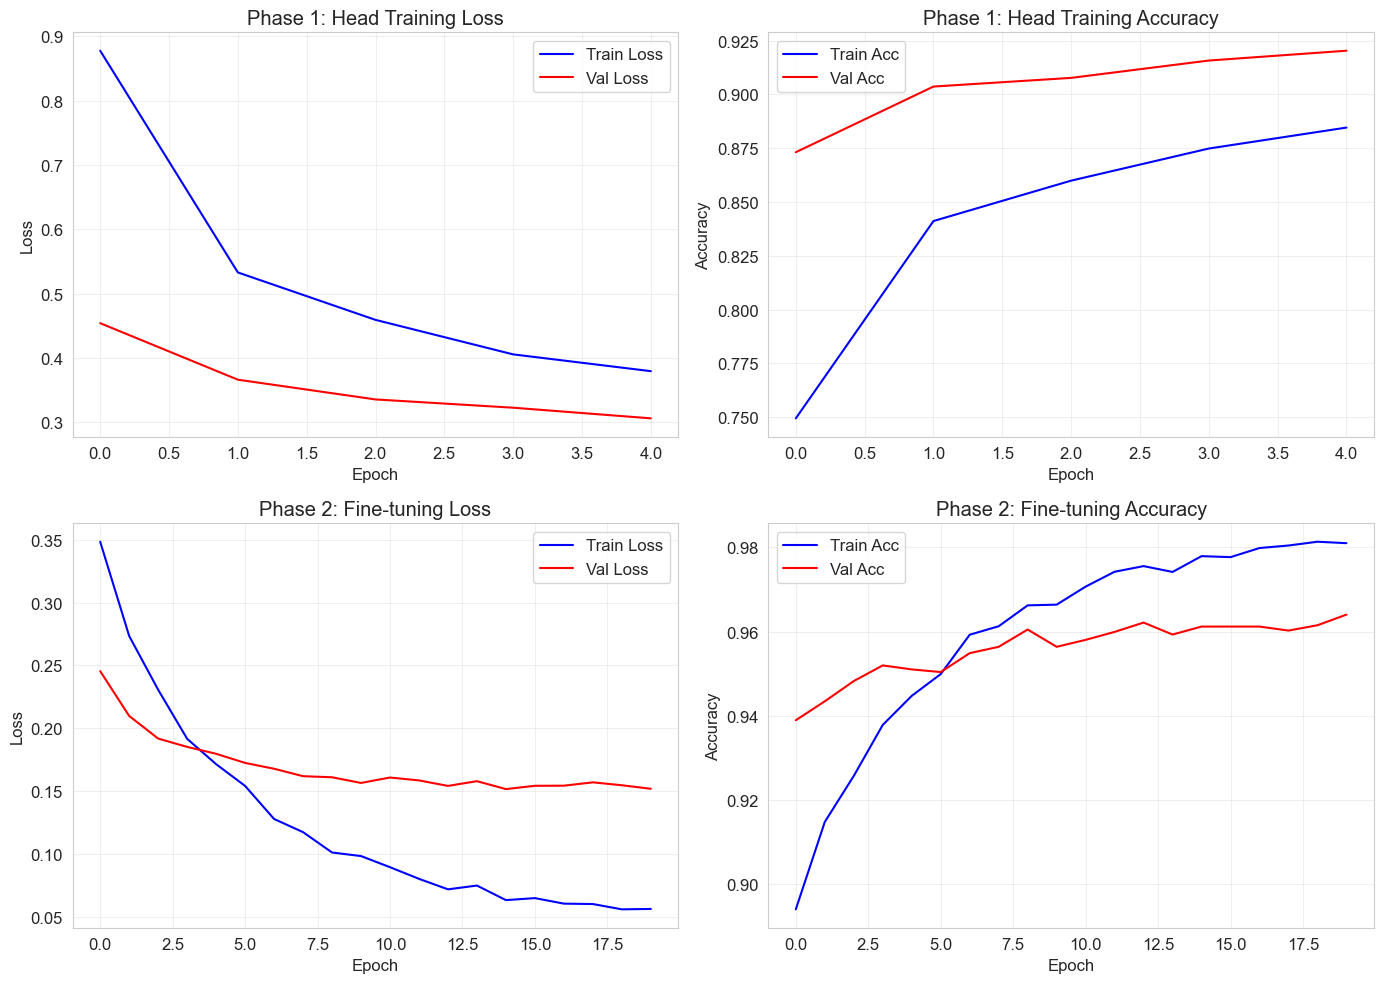

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Phase 1 Loss
axes[0, 0].plot(train_losses_phase1, 'b-', label='Train Loss')
axes[0, 0].plot(val_losses_phase1, 'r-', label='Val Loss')
axes[0, 0].set_title('Phase 1: Head Training Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Phase 1 Accuracy
axes[0, 1].plot(train_accs_phase1, 'b-', label='Train Acc')
axes[0, 1].plot(val_accs_phase1, 'r-', label='Val Acc')
axes[0, 1].set_title('Phase 1: Head Training Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Phase 2 Loss
axes[1, 0].plot(train_losses_phase2, 'b-', label='Train Loss')
axes[1, 0].plot(val_losses_phase2, 'r-', label='Val Loss')
axes[1, 0].set_title('Phase 2: Fine-tuning Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Phase 2 Accuracy
axes[1, 1].plot(train_accs_phase2, 'b-', label='Train Acc')
axes[1, 1].plot(val_accs_phase2, 'r-', label='Val Acc')
axes[1, 1].set_title('Phase 2: Fine-tuning Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



Eğitim sürecinin grafiklerini oluşturdum.


📈 DETAYLI PERFORMANS METRİKLERİ

📊 Ana Performans Metrikleri:


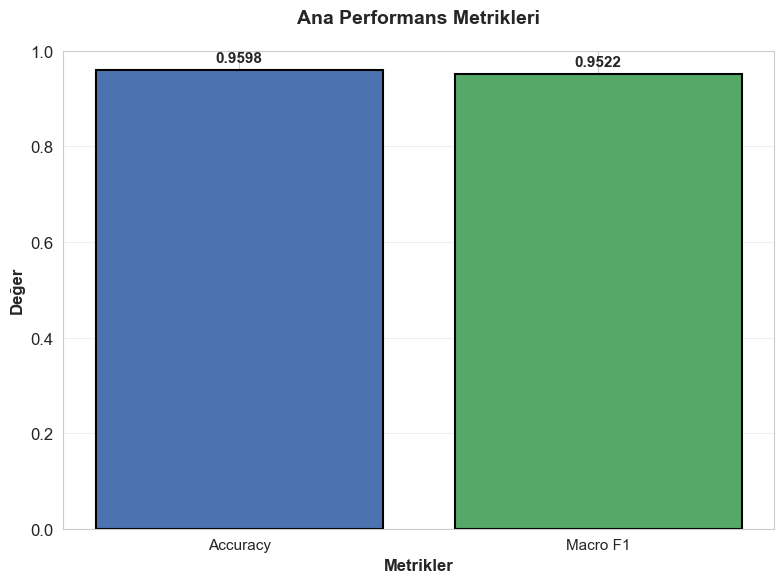

   Accuracy: 0.9598
   Macro F1: 0.9522


In [49]:

print("\n" + "="*60)
print("📈 DETAYLI PERFORMANS METRİKLERİ")
print("="*60)

#Ana Performans Metrikleri Görseli
print("\n📊 Ana Performans Metrikleri:")

main_metrics = {
    "Metric": ["Accuracy", "Macro F1"],
    "Value": [accuracy, macro_f1]
}

fig, ax = plt.subplots(figsize=(8, 6))
x_pos = np.arange(len(main_metrics["Metric"]))
values = [accuracy, macro_f1]
colors = ["#4C72B0", "#55A868"]

bars = ax.bar(x_pos, values, color=colors, edgecolor="black", linewidth=1.5)
ax.set_xlabel("Metrikler", fontsize=12, fontweight="bold")
ax.set_ylabel("Değer", fontsize=12, fontweight="bold")
ax.set_title("Ana Performans Metrikleri", fontsize=14, fontweight="bold", pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(main_metrics["Metric"], fontsize=11)
ax.set_ylim(0, 1.0)
ax.grid(True, alpha=0.3, axis='y')

for bar, value in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{value:.4f}', ha='center', va='bottom', fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"   Accuracy: {accuracy:.4f}")
print(f"   Macro F1: {macro_f1:.4f}")



 Accuracy ve Macro F1 değerlerini çubuk grafikte gösterdim. 


📊 Diğer Performans Metrikleri:


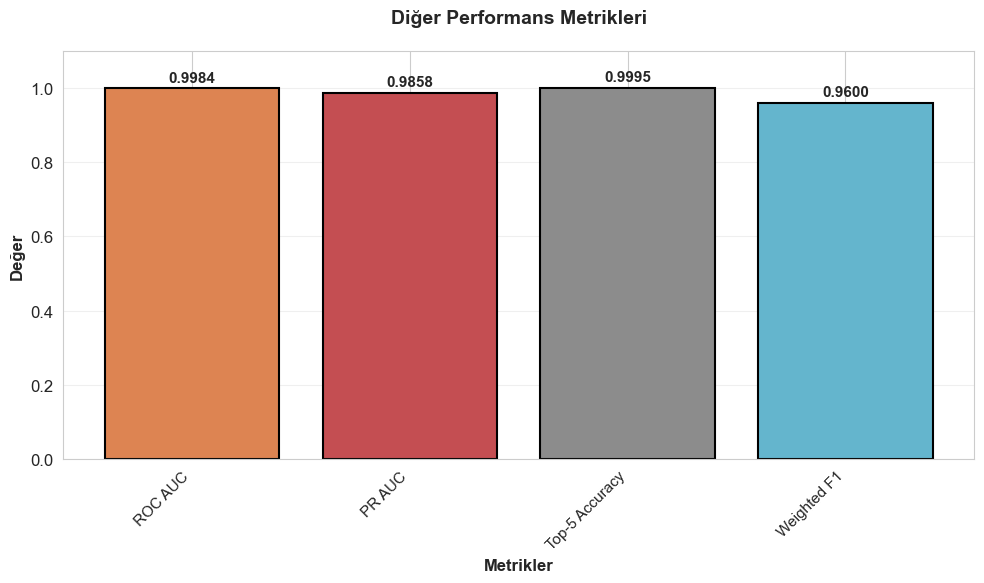

   ROC AUC: 0.9984
   PR AUC: 0.9858
   Top-5 Accuracy: 0.9995
   Weighted F1: 0.9600


In [50]:
#Diğer Performans Metrikleri

print("\n📊 Diğer Performans Metrikleri:")

other_metrics = {
    "Metric": ["ROC AUC", "PR AUC", "Top-5 Accuracy", "Weighted F1"],
    "Value": [roc_auc, macro_pr_auc, top5_acc if top5_acc else 0, weighted_f1]
}

fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(other_metrics["Metric"]))
values = other_metrics["Value"]
colors = ["#DD8452", "#C44E52", "#8C8C8C", "#64B5CD"]

bars = ax.bar(x_pos, values, color=colors, edgecolor="black", linewidth=1.5)
ax.set_xlabel("Metrikler", fontsize=12, fontweight="bold")
ax.set_ylabel("Değer", fontsize=12, fontweight="bold")
ax.set_title("Diğer Performans Metrikleri", fontsize=14, fontweight="bold", pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(other_metrics["Metric"], fontsize=11, rotation=45, ha="right")
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

for bar, value in zip(bars, values):
    height = bar.get_height()
    if not np.isnan(value):
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{value:.4f}', ha='center', va='bottom', fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"   ROC AUC: {roc_auc:.4f}")
print(f"   PR AUC: {macro_pr_auc:.4f}")
if top5_acc:
    print(f"   Top-5 Accuracy: {top5_acc:.4f}")
print(f"   Weighted F1: {weighted_f1:.4f}")



Diğer performans metriklerini görselleştirdim. ROC AUC, PR AUC, Top-5 Accuracy ve Weighted F1 değerlerini çubuk grafikte gösterdim.

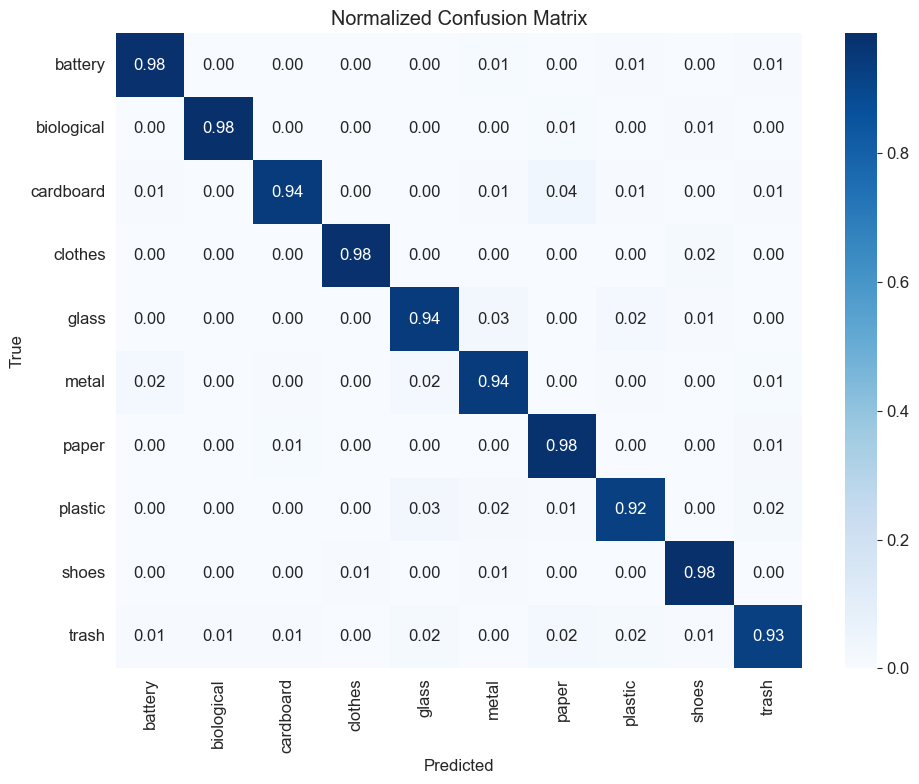

In [51]:

cm = confusion_matrix(all_labels, all_preds, normalize="true")
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()



Normalize edilmiş karışıklık matrisi oluşturdum. Her sınıf için doğru ve yanlış tahmin oranlarını gösterdim

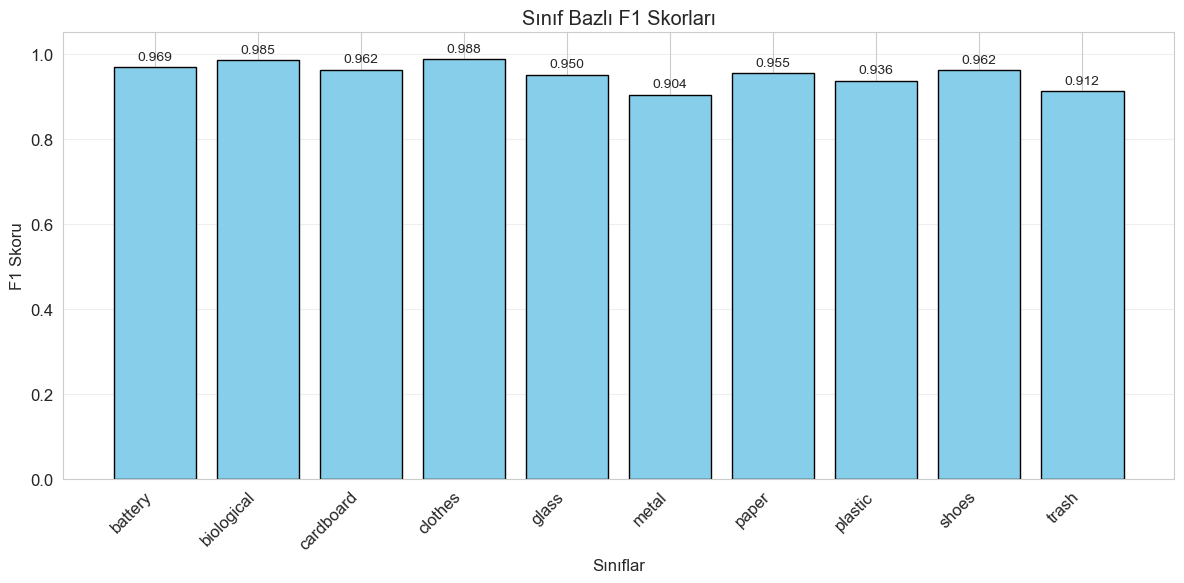

In [52]:
# Sınıf Bazlı F1 Skorları Görselleştirmesi

# F1 skorlarını hesapla
from sklearn.metrics import f1_score
f1_scores = f1_score(all_labels, all_preds, average=None)

# Grafik
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(class_names))

bars = ax.bar(x_pos, f1_scores, color='skyblue', edgecolor="black")
ax.set_xlabel("Sınıflar")
ax.set_ylabel("F1 Skoru")
ax.set_title("Sınıf Bazlı F1 Skorları")
ax.set_xticks(x_pos)
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis='y')

# Değerleri yaz
for bar, score in zip(bars, f1_scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{score:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Her sınıf için F1 skorlarını görselleştirdim. 

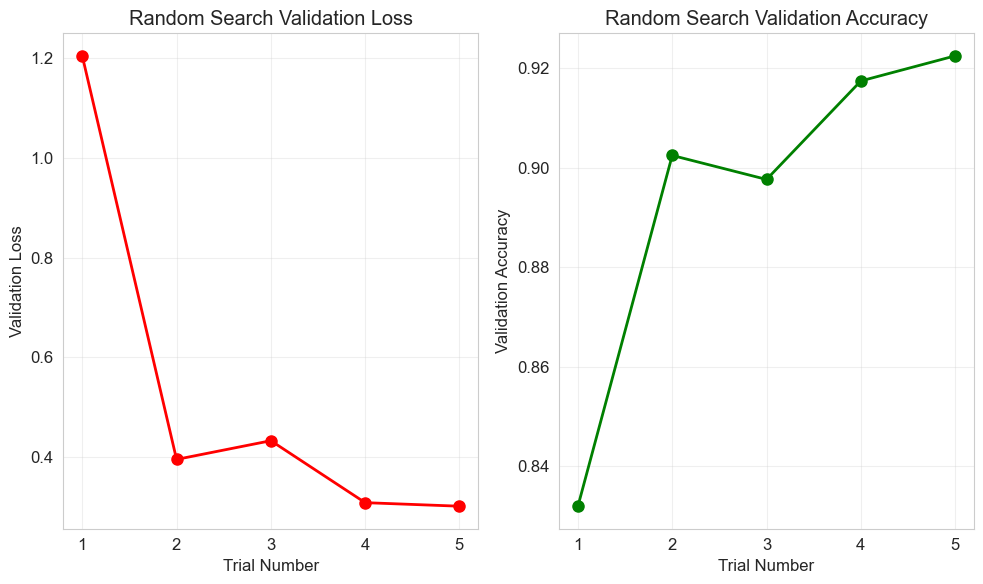

In [53]:
#Random Search Sonuçları
plt.figure(figsize=(10, 6))
trials = range(1, len(all_results) + 1)
val_losses = [r['best_val_loss'] for r in all_results]
val_accs = [r['best_val_acc'] for r in all_results]

plt.subplot(1, 2, 1)
plt.plot(trials, val_losses, 'o-', color='red', linewidth=2, markersize=8)
plt.xlabel('Trial Number')
plt.ylabel('Validation Loss')
plt.title('Random Search Validation Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(trials, val_accs, 'o-', color='green', linewidth=2, markersize=8)
plt.xlabel('Trial Number')
plt.ylabel('Validation Accuracy')
plt.title('Random Search Validation Accuracy')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



Random search denemelerinin sonuçlarını görselleştirdim. Her deneme için validation loss ve accuracy değerlerini grafikte gösterdim.


📊 ROC Eğrileri (One-vs-Rest):


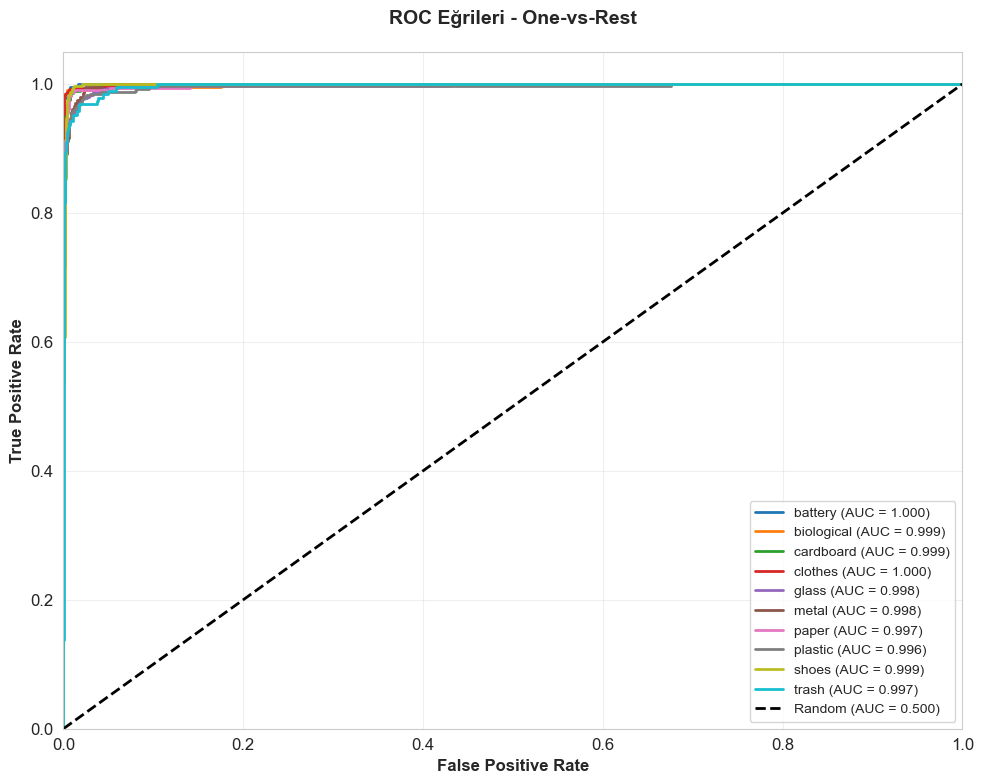

In [54]:

#ROC Eğrileri (One-vs-Rest)

print("\n📊 ROC Eğrileri (One-vs-Rest):")

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

for class_idx in range(num_classes):
    # Binary label oluştur
    y_true_binary = (all_labels == class_idx).astype(int)
    y_score = all_probs[:, class_idx]
    
    fpr, tpr, _ = roc_curve(y_true_binary, y_score)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, 
             label=f'{class_names[class_idx]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight="bold")
plt.ylabel('True Positive Rate', fontsize=12, fontweight="bold")
plt.title('ROC Eğrileri - One-vs-Rest', fontsize=14, fontweight="bold", pad=20)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



Modelin her sınıfı ne kadar iyi ayırt edebildiğini görselleştirmek için ROC eğrileri çizdim.


📊 Precision-Recall Eğrileri:
   battery        : Support = 189, PR AUC = 0.996
   biological     : Support = 200, PR AUC = 0.994
   cardboard      : Support = 365, PR AUC = 0.993
   clothes        : Support = 1065, PR AUC = 0.999
   glass          : Support = 612, PR AUC = 0.990
   metal          : Support = 204, PR AUC = 0.974
   paper          : Support = 336, PR AUC = 0.987
   plastic        : Support = 397, PR AUC = 0.983
   shoes          : Support = 395, PR AUC = 0.989
   trash          : Support = 190, PR AUC = 0.953


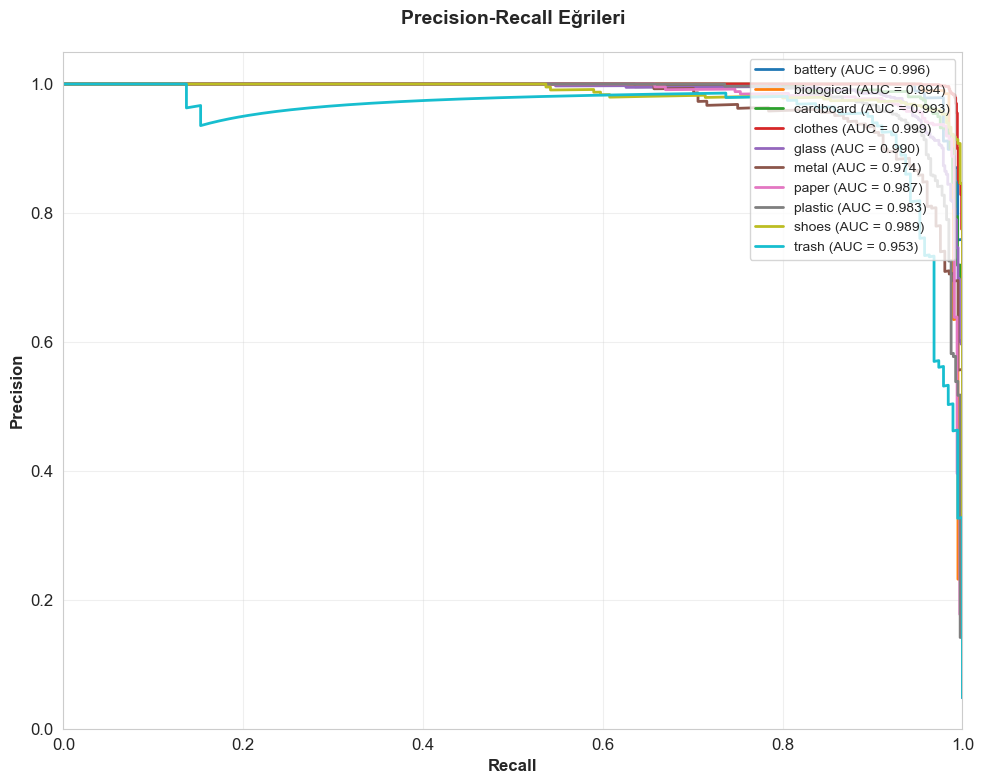

In [55]:

#Precision-Recall Eğrileri

print("\n📊 Precision-Recall Eğrileri:")

plt.figure(figsize=(10, 8))

for class_idx in range(num_classes):
    y_true_binary = (all_labels == class_idx).astype(int)
    y_score = all_probs[:, class_idx]
    
    precision, recall, _ = precision_recall_curve(y_true_binary, y_score)
    pr_auc = auc(recall, precision)
    
    plt.plot(recall, precision, lw=2, 
             label=f'{class_names[class_idx]} (AUC = {pr_auc:.3f})')

for class_idx in range(num_classes):
    support = np.sum(all_labels == class_idx)
    print(f"   {class_names[class_idx]:15}: Support = {support}, PR AUC = {pr_auc_scores[class_idx]:.3f}")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize=12, fontweight="bold")
plt.ylabel('Precision', fontsize=12, fontweight="bold")
plt.title('Precision-Recall Eğrileri', fontsize=14, fontweight="bold", pad=20)
plt.legend(loc="upper right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



Her sınıf için Precision-Recall eğrileri çizdim. Dengesiz veri setlerinde daha bilgilendirici olan bu metriği kullanarak modelin her sınıf için kesinlik ve duyarlılık dengesini görselleştirdim


📊 En Sık Karıştırılan Sınıf Çiftleri:


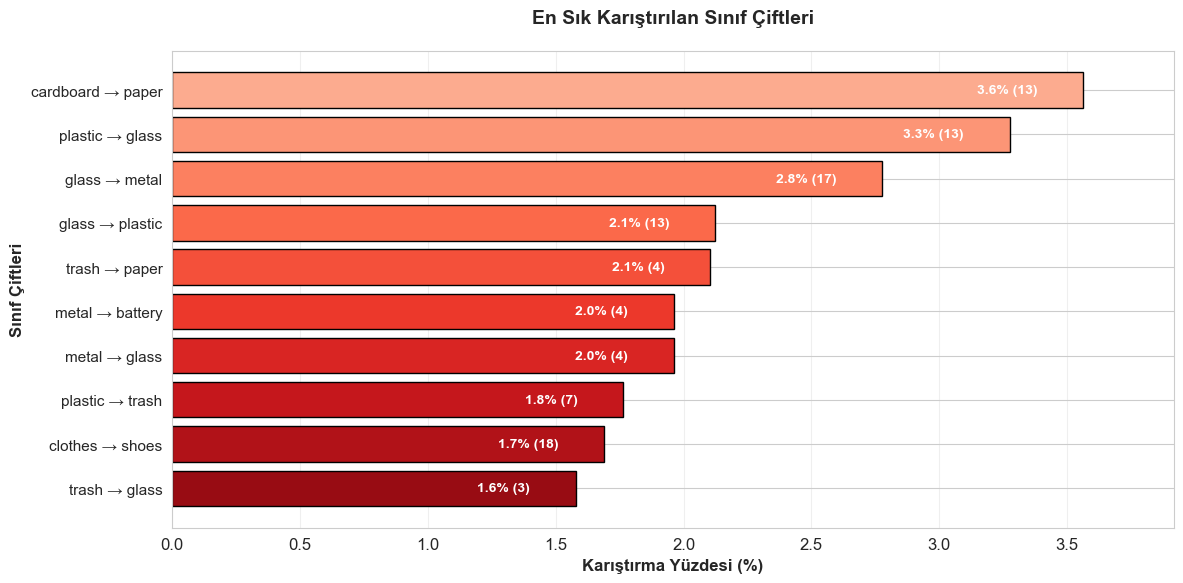


   Karıştırma Yüzdeleri:
   cardboard → paper        : 3.6% (13 örnek)
   plastic → glass          : 3.3% (13 örnek)
   glass → metal            : 2.8% (17 örnek)
   glass → plastic          : 2.1% (13 örnek)
   trash → paper            : 2.1% (4 örnek)
   metal → battery          : 2.0% (4 örnek)
   metal → glass            : 2.0% (4 örnek)
   plastic → trash          : 1.8% (7 örnek)
   clothes → shoes          : 1.7% (18 örnek)
   trash → glass            : 1.6% (3 örnek)


In [56]:

#En Sık Karıştırılan Sınıf Çiftleri

print("\n📊 En Sık Karıştırılan Sınıf Çiftleri:")

cm_raw = confusion_matrix(all_labels, all_preds)
confusion_pairs = []

for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm_raw[i, j] > 0:
            percentage = cm_raw[i, j] / cm_raw[i].sum() * 100
            confusion_pairs.append({
                'class_pair': f'{class_names[i]} → {class_names[j]}',
                'count': cm_raw[i, j],
                'percentage': percentage
            })

confusion_pairs.sort(key=lambda x: x['percentage'], reverse=True)

top_confusion_pairs = confusion_pairs[:min(10, len(confusion_pairs))]

fig, ax = plt.subplots(figsize=(12, 6))
y_pos = np.arange(len(top_confusion_pairs))
percentages = [pair['percentage'] for pair in top_confusion_pairs]
class_pairs = [pair['class_pair'] for pair in top_confusion_pairs]
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(top_confusion_pairs)))

bars = ax.barh(y_pos, percentages, color=colors, edgecolor="black", linewidth=1)
ax.set_xlabel('Karıştırma Yüzdesi (%)', fontsize=12, fontweight="bold")
ax.set_ylabel('Sınıf Çiftleri', fontsize=12, fontweight="bold")
ax.set_title('En Sık Karıştırılan Sınıf Çiftleri', fontsize=14, fontweight="bold", pad=20)
ax.set_yticks(y_pos)
ax.set_yticklabels(class_pairs, fontsize=11)
ax.invert_yaxis()  # En yüksek değer üstte
ax.set_xlim(0, max(percentages) * 1.1)
ax.grid(True, alpha=0.3, axis='x')

for bar, percentage, count in zip(bars, percentages, [pair['count'] for pair in top_confusion_pairs]):
    width = bar.get_width()
    if width > max(percentages) * 0.1:  
        ax.text(width - max(percentages)*0.05, bar.get_y() + bar.get_height()/2,
                f'{percentage:.1f}% ({count})', 
                ha='right', va='center', color='white', fontsize=10, fontweight="bold")
    else:  
        ax.text(width + max(percentages)*0.01, bar.get_y() + bar.get_height()/2,
                f'{percentage:.1f}% ({count})', 
                ha='left', va='center', color='black', fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

print("\n   Karıştırma Yüzdeleri:")
for pair in top_confusion_pairs:
    print(f"   {pair['class_pair']:25}: {pair['percentage']:.1f}% ({pair['count']} örnek)")



Modelin en çok hangi sınıf çiftlerini karıştırdığını analiz ettim. Karışıklık matrisinden yararlanarak bir sınıfın başka bir sınıf ile ne sıklıkta karıştırıldığını hesapladım.

In [60]:
print("PERFORMANS TABLOSU")

detailed_performance = []
for class_idx, class_name in enumerate(class_names):
    # Binary sınıflandırma için tüm veri üzerinde maskeler
    y_true_binary = (all_labels == class_idx).astype(int)
    y_pred_binary = (all_preds == class_idx).astype(int)
    
    # Tüm veri üzerinde confusion matrix değerleri
    tn = np.sum((y_pred_binary == 0) & (y_true_binary == 0))
    fp = np.sum((y_pred_binary == 1) & (y_true_binary == 0))
    fn = np.sum((y_pred_binary == 0) & (y_true_binary == 1))
    tp = np.sum((y_pred_binary == 1) & (y_true_binary == 1))
    
    total_class_samples = tp + fn  # Bu sınıfa ait gerçek örnek sayısı
    
    # METRİKLER - DOĞRU FORMÜLLER
    precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_val = 2 * precision_val * recall_val / (precision_val + recall_val) if (precision_val + recall_val) > 0 else 0
    accuracy_val = (tp + tn) / len(all_labels)  # GERÇEK sınıf accuracy
    
    # En çok karıştığı sınıf (confusion matrix'ten)
    if class_idx < cm_raw.shape[1]:
        confusions = [(j, cm_raw[class_idx, j]) for j in range(num_classes) if j != class_idx]
        if confusions:
            most_confused_idx, most_confused_count = max(confusions, key=lambda x: x[1])
            confusion_percentage = most_confused_count / cm_raw[class_idx].sum() * 100
            most_confused = f"{class_names[most_confused_idx]} ({confusion_percentage:.1f}%)"
        else:
            most_confused = "-"
    else:
        most_confused = "-"
    
    detailed_performance.append({
        "Sınıf": class_name,
        "Toplam": total_class_samples,  # Gerçek örnek sayısı
        "Doğru": tp,
        "Accuracy": accuracy_val * 100,  # DÜZELTİLDİ: (TP+TN)/Tüm_Örnekler
        "Precision": precision_val * 100,
        "Recall": recall_val * 100,
        "F1-Score": f1_val * 100,
        "En Çok Karıştığı": most_confused
    })

# Geri kalan kod (dataframe oluşturma ve styling) AYNI KALABİLİR
summary_df = pd.DataFrame(detailed_performance)

styled_df = summary_df.style\
    .format({
        'Accuracy': '{:.2f}%',
        'Precision': '{:.2f}%', 
        'Recall': '{:.2f}%',
        'F1-Score': '{:.2f}%'
    })\
    .background_gradient(subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'], 
                        cmap='YlGn', vmin=85, vmax=100)\
    .set_properties(**{
        'text-align': 'center',
        'font-family': 'Arial, sans-serif'
    })\
    .set_table_styles([
        {'selector': 'thead th',
         'props': [('background-color', '#2E86C1'), 
                  ('color', 'white'),
                  ('font-weight', 'bold'),
                  ('text-align', 'center'),
                  ('font-size', '12px'),
                  ('padding', '8px'),
                  ('border', '1px solid #ddd')]},
        {'selector': 'td',
         'props': [('text-align', 'center'),
                  ('padding', '6px'),
                  ('border', '1px solid #ddd'),
                  ('font-size', '11px')]},
        {'selector': 'tr:nth-child(even)',
         'props': [('background-color', '#f9f9f9')]},
        {'selector': 'tr:nth-child(odd)',
         'props': [('background-color', 'white')]},
        {'selector': 'tr:hover',
         'props': [('background-color', '#D6EAF8'),
                  ('cursor', 'pointer')]},
        {'selector': '',
         'props': [('border-collapse', 'collapse'),
                  ('width', '100%')]}
    ])\
    .set_caption(f'Toplam Test Örnekleri: {len(all_labels)} | Genel Accuracy: {accuracy*100:.2f}%')\
    .hide(axis='index')

try:
    from IPython.display import display
    display(styled_df)
except Exception as e:
    print(f"⚠️  Tablo gösterilemedi: {e}")
    print("\nAlternatif basit tablo:")
    print(summary_df.to_string(index=False, formatters={
        'Accuracy': '{:.2f}%'.format,
        'Precision': '{:.2f}%'.format,
        'Recall': '{:.2f}%'.format,
        'F1-Score': '{:.2f}%'.format
    }))

PERFORMANS TABLOSU


Sınıf,Toplam,Doğru,Accuracy,Precision,Recall,F1-Score,En Çok Karıştığı
battery,189,185,99.70%,95.85%,97.88%,96.86%,metal (1.1%)
biological,200,197,99.85%,98.50%,98.50%,98.50%,paper (1.0%)
cardboard,365,344,99.32%,98.29%,94.25%,96.22%,paper (3.6%)
clothes,1065,1042,99.34%,99.71%,97.84%,98.77%,shoes (1.7%)
glass,612,575,98.48%,96.15%,93.95%,95.04%,metal (2.8%)
metal,204,192,98.96%,86.88%,94.12%,90.35%,battery (2.0%)
paper,336,328,99.22%,93.45%,97.62%,95.49%,trash (1.2%)
plastic,397,367,98.74%,94.83%,92.44%,93.62%,glass (3.3%)
shoes,395,388,99.22%,94.17%,98.23%,96.16%,clothes (0.8%)
trash,190,176,99.14%,89.80%,92.63%,91.19%,paper (2.1%)


Detaylı performans tablosu oluşturdum. Her sınıf için doğruluk, kesinlik, duyarlılık ve F1 skoru hesapladım. Ayrıca her sınıfın en çok hangi sınıfla karıştığını ve yüzdesini gösterdim. 

In [62]:
# En iyi ve en kötü performans gösteren sınıflar
best_f1 = summary_df.loc[summary_df['F1-Score'].idxmax()]
worst_f1 = summary_df.loc[summary_df['F1-Score'].idxmin()]

best_acc = summary_df.loc[summary_df['Accuracy'].idxmax()]
worst_acc = summary_df.loc[summary_df['Accuracy'].idxmin()]

print(f"\n🏆 EN İYİ PERFORMANS:")
print(f"   • F1-Score: {best_f1['Sınıf']} ({best_f1['F1-Score']:.1f}%)")
print(f"   • Accuracy: {best_acc['Sınıf']} ({best_acc['Accuracy']:.1f}%)")

print(f"\n⚠️  EN DÜŞÜK PERFORMANS:")
print(f"   • F1-Score: {worst_f1['Sınıf']} ({worst_f1['F1-Score']:.1f}%)")
print(f"   • Accuracy: {worst_acc['Sınıf']} ({worst_acc['Accuracy']:.1f}%)")

print(f"\n📈 STANDART SAPMALAR:")
print(f"   • F1-Score Std: {summary_df['F1-Score'].std():.1f}%")
print(f"   • Accuracy Std: {summary_df['Accuracy'].std():.1f}%")



🏆 EN İYİ PERFORMANS:
   • F1-Score: clothes (98.8%)
   • Accuracy: biological (99.8%)

⚠️  EN DÜŞÜK PERFORMANS:
   • F1-Score: metal (90.4%)
   • Accuracy: glass (98.5%)

📈 STANDART SAPMALAR:
   • F1-Score Std: 2.8%
   • Accuracy Std: 0.4%


Model performansının özetini çıkardım. En iyi ve en kötü performans gösteren sınıfları belirledim. Ortalama değerler ve standart sapmalar ile modelin genel istikrarını ölçtüm. 

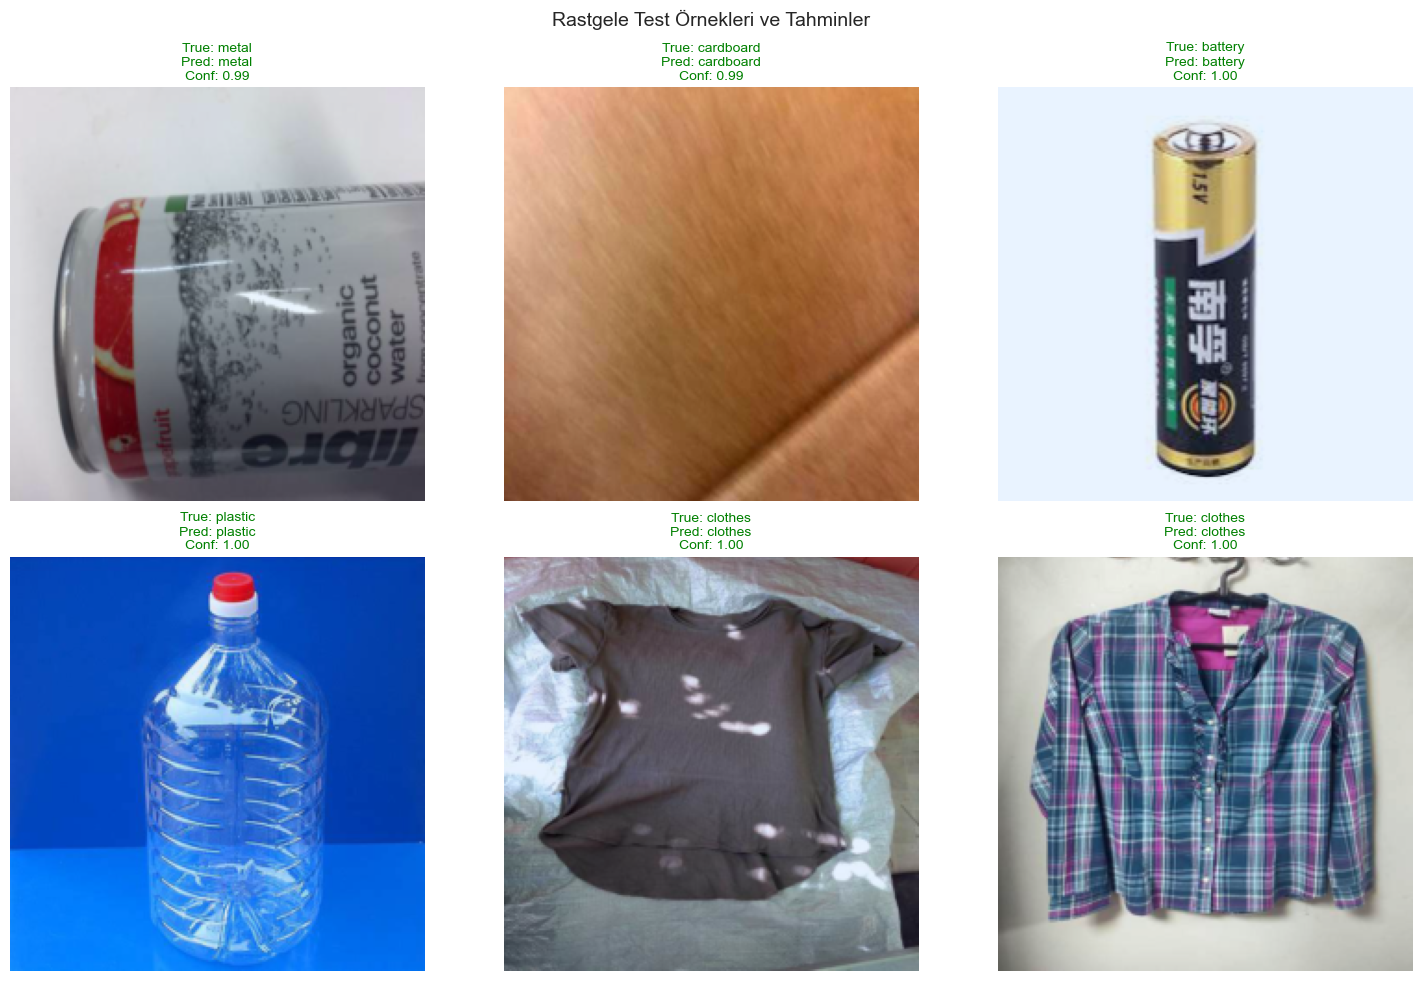

In [59]:

#ÖRNEK TAHMİNLER
def visualize_predictions(model, dataset, num_samples=6):
    """Rastgele örneklerle tahminleri göster"""
    indices = random.sample(range(len(dataset)), num_samples)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, ax in zip(indices, axes):
        sample = dataset[idx]
        image = sample["image"].unsqueeze(0).to(device)
        true_label = sample["label"]
        true_class = sample["class_name"]
        
        with torch.no_grad():
            outputs = model(image)
            probs = torch.softmax(outputs, dim=1)
            pred_prob, pred_label = torch.max(probs, dim=1)
        
        img = sample["image"].permute(1, 2, 0).cpu().numpy()
        img = (img - img.min()) / (img.max() - img.min())
        
        ax.imshow(img)
        ax.axis('off')
        
        pred_class = idx_to_class[pred_label.item()]
        is_correct = pred_label.item() == true_label
        
        color = 'green' if is_correct else 'red'
        ax.set_title(
            f"True: {true_class}\nPred: {pred_class}\nConf: {pred_prob.item():.2f}",
            color=color,
            fontsize=10
        )
    
    plt.suptitle("Rastgele Test Örnekleri ve Tahminler", fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_predictions(model, test_dataset, num_samples=6)


Rastgele test örneklerini görselleştirdim.Doğru tahminleri yeşil, yanlış tahminleri kırmızı renkle işaretledim. Böylece modelin gerçek dünyada nasıl performans gösterdiğini somut örneklerle göstermiş oldum.

In [73]:
# ============================================================================
# TÜM MODELLERİMİN PERFORMANS KARŞILAŞTIRMA TABLOSU
# ============================================================================

print("\n" + "="*70)
print("MODELLERİMİN PERFORMANS KARŞILAŞTIRMASI")
print("="*70)

 
all_models_results = [
    # MODEL 1: CNN+Dropout_4Katmanlı 
    {
        'Model': 'CNN+Dropout_4Katmanlı',
        'Accuracy': 0.7035,    
        'Precision': 0.7035,   
        'Recall': 0.6227,      
        'F1-Score': 0.6479   
    },
    
    # MODEL 2: CNN+Dropout_6Katmanlı
    {
        'Model': 'CNN+Dropout_6Katmanlı', 
        'Accuracy': 0.7889,    
        'Precision': 0.7598,   
        'Recall': 0.7378,      
        'F1-Score': 0.7478    
    },
    
    # MODEL 3: DenseNet121_BasitFineTuning
    {
        'Model': 'DenseNet121_BasitFineTuning',
        'Accuracy': 0.9598,  
        'Precision': 0.9476,
        'Recall': 0.9575,   
        'F1-Score': 0.9522   
    },
    
    # MODEL 4: DenseNet121_KademeliFineTuning
    {
        'Model': 'DenseNet121_KademeliFineTuning',
        'Accuracy': 0.9524,  
        'Precision': 0.9363,  
        'Recall': 0.9505,    
        'F1-Score': 0.9426     
    },
    
    # MODEL 5: ConvNeXt-Tiny
    {
        'Model': 'ConvNeXt-Tiny',
        'Accuracy': 0.9709,  
        'Precision': 0.9609, 
        'Recall': 0.9696,    
        'F1-Score': 0.9650   
    }
]


comparison_df = pd.DataFrame(all_models_results)
comparison_df.set_index('Model', inplace=True)


color_palette = {
    'Accuracy': '#1f77b4',    # Mavi
    'Precision': '#2ca02c',   # Yeşil
    'Recall': '#ff7f0e',      # Turuncu
    'F1-Score': '#d62728'     # Kırmızı
}

styled_df = comparison_df.style\
    .format("{:.4f}")\
    .background_gradient(subset=['Accuracy'], cmap='Blues', vmin=0.7, vmax=1.0)\
    .background_gradient(subset=['Precision'], cmap='Greens', vmin=0.7, vmax=1.0)\
    .background_gradient(subset=['Recall'], cmap='Oranges', vmin=0.7, vmax=1.0)\
    .background_gradient(subset=['F1-Score'], cmap='Reds', vmin=0.7, vmax=1.0)\
    .set_properties(**{
        'text-align': 'center',
        'font-family': 'Arial, sans-serif',
        'border': '1px solid #e0e0e0'
    })\
    .set_table_styles([
        {'selector': 'thead th',
         'props': [('background-color', '#2c3e50'), 
                  ('color', 'white'),
                  ('font-weight', 'bold'),
                  ('text-align', 'center'),
                  ('font-size', '12px'),
                  ('padding', '10px'),
                  ('border-bottom', '2px solid #34495e')]},
        {'selector': 'td',
         'props': [('text-align', 'center'),
                  ('padding', '8px'),
                  ('font-size', '12px'),
                  ('border', '1px solid #e0e0e0')]},
        {'selector': 'tr:hover',
         'props': [('background-color', '#f5f7fa')]}
    ])

# Tabloyu göster
try:
    from IPython.display import display
    display(styled_df)
except:
    print(comparison_df.round(4).to_string())





MODELLERİMİN PERFORMANS KARŞILAŞTIRMASI


,Accuracy,Precision,Recall,F1-Score
Model,,,,
CNN+Dropout_4Katmanlı,0.7035,0.7035,0.6227,0.6479
CNN+Dropout_6Katmanlı,0.7889,0.7598,0.7378,0.7478
DenseNet121_BasitFineTuning,0.9598,0.9476,0.9575,0.9522
DenseNet121_KademeliFineTuning,0.9524,0.9363,0.9505,0.9426
ConvNeXt-Tiny,0.9709,0.9609,0.9696,0.9650


GRAFİKLE KARŞILAŞTIRMA


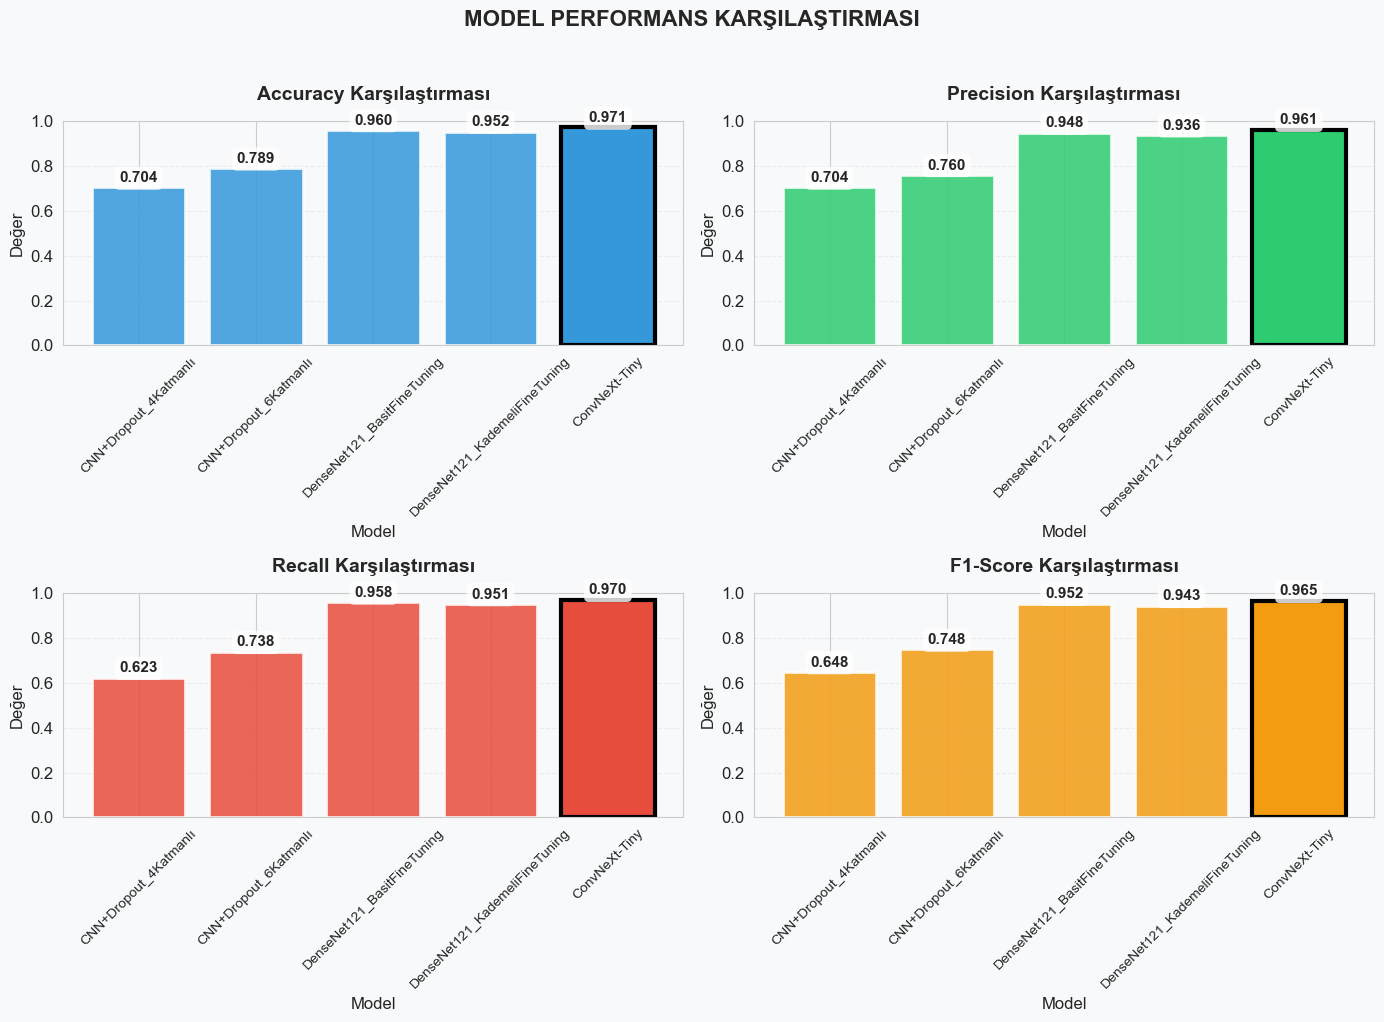

In [74]:
print("GRAFİKLE KARŞILAŞTIRMA")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('MODEL PERFORMANS KARŞILAŞTIRMASI', fontsize=16, fontweight='bold', y=1.02)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names_list = comparison_df.index.tolist()

bar_colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']  # Mavi, Yeşil, Kırmızı, Turuncu

for i, metric in enumerate(metrics):
    ax = axes[i//2, i%2]
    values = comparison_df[metric].values
    
    bars = ax.bar(model_names_list, values, color=bar_colors[i], alpha=0.85, edgecolor='white', linewidth=2)
    ax.set_title(f'{metric} Karşılaştırması', fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel('Değer', fontsize=12)
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylim([0, 1.0])
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.tick_params(axis='x', rotation=45, labelsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # En yüksek çubuğu işaretle
    best_idx = np.argmax(values)
    bars[best_idx].set_alpha(1.0)
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(3)
    

    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{val:.3f}', ha='center', va='bottom', 
                fontsize=11, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor='none'))


fig.patch.set_facecolor('#f8f9fa')
for ax in axes.flatten():
    ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()



In [75]:
#KARŞILAŞTIRMA ÖZETİ

print("PERFORMANS ANALİZ ÖZETİ")


# En iyi model
best_model_acc = comparison_df['Accuracy'].idxmax()
best_model_f1 = comparison_df['F1-Score'].idxmax()

print(f"\n🏆 EN İYİ PERFORMANS:")
print(f"   • En yüksek Accuracy  : {best_model_acc} ({comparison_df.loc[best_model_acc, 'Accuracy']:.4f})")
print(f"   • En yüksek F1-Score  : {best_model_f1} ({comparison_df.loc[best_model_f1, 'F1-Score']:.4f})")

print(f"\n📊 GENEL İSTATİSTİKLER:")
print(f"   • Toplam Model Sayısı : {len(comparison_df)}")
print(f"   • En yüksek Accuracy  : {comparison_df['Accuracy'].max():.4f}")
print(f"   • En düşük Accuracy   : {comparison_df['Accuracy'].min():.4f}")
print(f"   • Accuracy Farkı      : {(comparison_df['Accuracy'].max() - comparison_df['Accuracy'].min()):.4f}")
print(f"   • Ortalama Accuracy   : {comparison_df['Accuracy'].mean():.4f}")


PERFORMANS ANALİZ ÖZETİ

🏆 EN İYİ PERFORMANS:
   • En yüksek Accuracy  : ConvNeXt-Tiny (0.9709)
   • En yüksek F1-Score  : ConvNeXt-Tiny (0.9650)

📊 GENEL İSTATİSTİKLER:
   • Toplam Model Sayısı : 5
   • En yüksek Accuracy  : 0.9709
   • En düşük Accuracy   : 0.7035
   • Accuracy Farkı      : 0.2674
   • Ortalama Accuracy   : 0.8751
